In [17]:
# LangGraph에서 상태 그래프를 만들기 위한 클래스와
# 그래프의 시작/끝을 나타내는 상수를 가져옵니다.
from langgraph.graph import StateGraph, START, END

# 딕셔너리 형태의 타입(키/값 타입을 명시한 dict)을
# 정의할 수 있게 해주는 도구입니다.
from typing_extensions import TypedDict

# Literal: 특정 값들만 허용하는 타입을 만들 때 사용합니다.
# 예: Literal["node_three", "node_four"] → "node_three" 또는 "node_four" 만 반환 가능
from typing import Literal

In [18]:
# 그래프에서 오고 가는 상태의 모양을 정의합니다.
# seed: 조건 분기에 사용할 숫자(짝수/홀수에 따라 다른 경로로 갑니다)
class State(TypedDict):
  seed: int

# 위에서 정의한 State 타입을 사용하는 상태 그래프를 만듭니다.
graph_builder = StateGraph(State)

In [19]:
# 각 노드는 state 를 받아서, 필요하면 수정한 state 를 반환합니다.
# 여기서는 모두 빈 dict 를 반환하므로 상태는 그대로 유지됩니다.
# print 로 실행 흐름을 확인할 수 있습니다.

def node_one(state: State):
  print("node_one ->", state)
  return {}

def node_two(state: State):
  print("node_two ->", state)
  return {}

def node_three(state: State):
  print("node_three ->", state)
  return {}

def node_four(state: State):
  print("node_four ->", state)
  return {}
  

In [20]:
# 그래프에 사용할 노드들을 등록합니다.
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)
graph_builder.add_node("node_three", node_three)
graph_builder.add_node("node_four", node_four)

# decide_path: "조건부 간선"에서 다음에 어느 노드로 갈지 결정하는 함수입니다.
# state["seed"] % 2 == 0 → seed 가 짝수면 True, 홀수면 False 를 반환합니다.
# 반환값(True/False)에 따라 add_conditional_edges 의 매핑에서 다음 노드를 찾습니다.
def decide_path(state: State):
  return state["seed"]   % 2 == 0

# add_conditional_edges: "조건에 따라 분기하는 간선"을 추가합니다.
# - 첫 번째 인자: 출발 노드(여기서는 START)
# - 두 번째 인자: 다음 노드를 결정하는 함수(decide_path)
# - 세 번째 인자: decide_path 의 반환값 → 다음 노드 이름 매핑
#   True  → "node_one" (seed 가 짝수일 때)
#   False → "node_two" (seed 가 홀수일 때)
#   "hello" → END (decide_path 가 "hello" 를 반환하면 END 로, 현재는 사용되지 않음)
graph_builder.add_conditional_edges(
  START,
  decide_path,
  {
    True: "node_one",
    False: "node_two",
    "hello": END,
  }
)
# node_one 에서는 항상 node_two 로만 갑니다. (일반 간선)
graph_builder.add_edge("node_one", "node_two")

# node_two 에서도 decide_path 로 분기합니다.
# seed 가 짝수면 node_three, 홀수면 node_four 로 갑니다.
graph_builder.add_conditional_edges(
  "node_two",
  decide_path,
  {
    True: "node_three",
    False: "node_four",
    "hello": END,
  },
)

# node_three, node_four 모두 END 로 연결합니다.
graph_builder.add_edge("node_four", END)
graph_builder.add_edge("node_three", END)



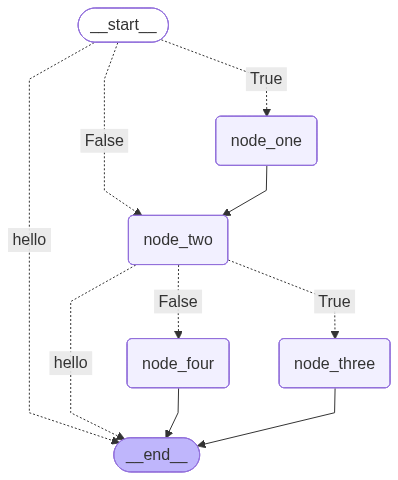

In [21]:
# 지금까지 정의한 노드와 간선(일반/조건부)을 이용해서
# 실제로 실행 가능한 그래프 객체를 만듭니다.
graph = graph_builder.compile()

# 예: graph.invoke({"seed": 2}) → 짝수이므로
#     START -> node_one -> node_two -> node_three -> END
# 예: graph.invoke({"seed": 3}) → 홀수이므로
#     START -> node_two -> node_four -> END
graph